# Cross-Asset Strategy Optimization
## 1. Executive Summary

### 1.1. Overview
This project conducts a comprehensive backtest and optimization of the **Moving Average (MA) Crossover strategy**. The study focuses on transition from a standard lagging model to an optimized high-sensitivity model to enhance risk-adjusted returns.

### 1.2. Key Research Questions

- Can we reduce the Maximum Drawdown (MDD) of the S&P 500 during market crashes by optimizing MA parameters?

- Does a strategy optimized for equities maintain its **robustness** when applied to high-volatility assets like Bitcoin?

### 1.3. Quick Summary of Achievements

- **Optimization**: Successfully mitigated 2020 crash risks in SPY by identifying more responsive entry/exit windows.

- **Alpha Generation**: Proved that the optimized strategy nearly doubles the 'Buy & Hold' returns in the cryptocurrency market.

- **Scalability**: Confirmed the potential for live deployment via the **Interactive Brokers API**.

## 2. Base Strategy Analysis: The 50/200 Model
### 2.1. Defining the Baseline Strategy
To establish a performance benchmark, I first implemented the most widely recognized trend-following model: the **50-day and 200-day Moving Average (MA) Crossover**. This strategy, often referred to as the "Golden Cross" for entries and "Death Cross" for exits, is used to identify long-term market trends while filtering out daily price noise.

- **Buy Signal**: Short-term MA (50-day) > Long-term MA (200-day).

- **Sell Signal**: Short-term MA (50-day) < Long-term MA (200-day).

### 2.2. Implementation & Technical Integrity
The initial backtest was conducted on the **SPY (S&P 500 ETF)** to measure the strategy's effectiveness in a mature equity market.

- **Look-ahead Bias Mitigation**: I applied a *shift(1)* to the signals, ensuring that trades are executed on the day following the crossover, reflecting realistic trading conditions.

- **Preprocessing**: Flattened the Multi-index columns and removed initial null values (NaN) caused by the 200-day calculation lag to ensure data accuracy.

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
ticker = 'SPY'
df_spy = yf.download(ticker, start = '2019-01-01')

[*********************100%***********************]  1 of 1 completed


In [4]:
if df_spy.empty:
    print("Data not available. Check on the ticker name")
else:
    if isinstance(df_spy.columns, pd.MultiIndex):
        df_spy.columns = df_spy.columns.get_level_values(0)

    df_spy['MA50'] = df_spy['Close'].rolling(window=50).mean()
    df_spy['MA200'] = df_spy['Close'].rolling(window=200).mean()            

    df_final = df_spy.dropna()

    print(df_final.tail())

Price            Close        High         Low        Open     Volume  \
Date                                                                    
2026-02-17  682.849976  684.940002  675.780029  680.140015   81354700   
2026-02-18  686.289978  689.150024  682.830017  684.020020   73570300   
2026-02-19  684.479980  686.179993  681.549988  683.840027   58649400   
2026-02-20  689.429993  690.059998  681.729980  682.320007  100034000   
2026-02-23  682.390015  690.000000  680.369995  687.830017   90421900   

Price             MA50       MA200  
Date                                
2026-02-17  686.892506  646.660675  
2026-02-18  686.970833  647.323883  
2026-02-19  686.987036  647.936949  
2026-02-20  687.143318  648.590874  
2026-02-23  687.170566  649.232946  


In [5]:
df_spy['Signal'] = 0.0
df_spy.loc[df_spy['MA50'] > df_spy['MA200'], 'Signal'] = 1.0

df_spy['Position'] = df_spy['Signal'].diff()

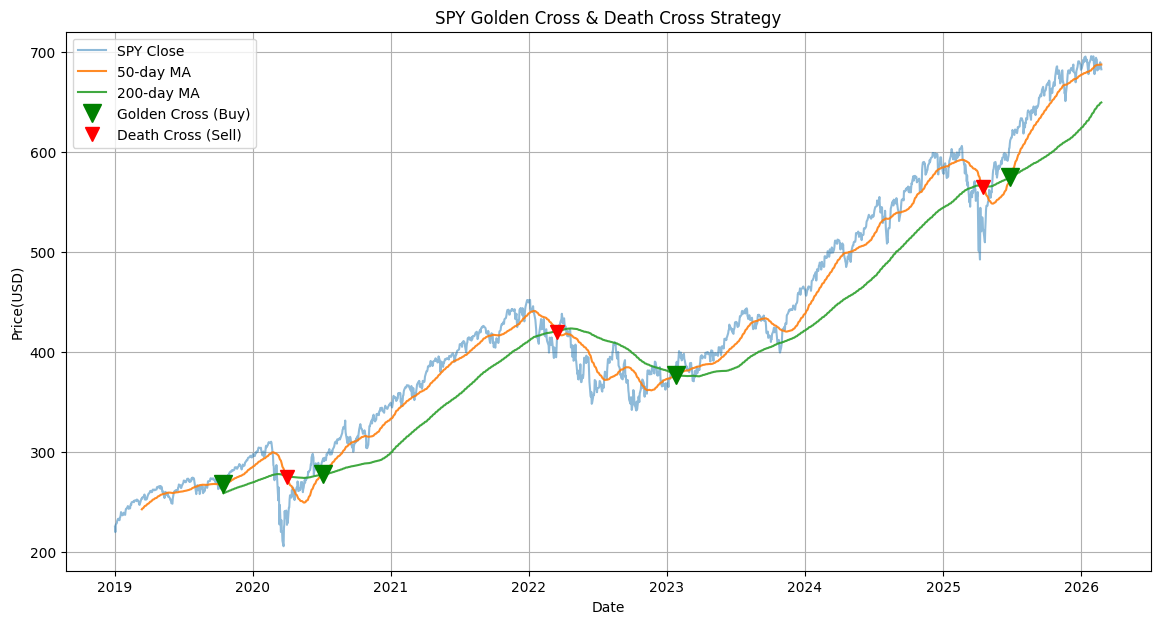

In [6]:
plt.figure(figsize = (14, 7))

plt.plot(df_spy['Close'], label = 'SPY Close', alpha = 0.5)
plt.plot(df_spy['MA50'], label = '50-day MA', alpha = 0.9)
plt.plot(df_spy['MA200'], label = '200-day MA', alpha = 0.9)

plt.plot(df_spy[df_spy['Position'] == 1].index,
         df_spy['MA50'][df_spy['Position'] == 1],
         'v', markersize = 13, color = 'g', label = 'Golden Cross (Buy)')

plt.plot(df_spy[df_spy['Position'] == -1].index,
         df_spy['MA50'][df_spy['Position'] == -1],
         'v', markersize = 10, color = 'r', label = 'Death Cross (Sell)')

plt.title(f'{ticker} Golden Cross & Death Cross Strategy')
plt.xlabel('Date')
plt.ylabel('Price(USD)')
plt.legend()
plt.grid()
plt.show()

In [7]:
df_spy['Market_Returns'] = df_spy['Close'].pct_change()
df_spy['Strategy_Returns'] = df_spy['Market_Returns'] * df_spy['Signal'].shift(1)

cum_market_returns = (1 + df_spy['Market_Returns']).cumprod()
cum_strategy_returns = (1+ df_spy['Strategy_Returns']).cumprod()

print(f'Final Market Cumulative Returns: {cum_market_returns.iloc[-1]:.2f}')
print(f'Final Strategy Cumulative Returns: {cum_strategy_returns.iloc[-1]:.2f}')

Final Market Cumulative Returns: 3.03
Final Strategy Cumulative Returns: 1.83


In [8]:
market_peak = cum_market_returns.cummax()
strategy_peak = cum_strategy_returns.cummax()

market_dd = (cum_market_returns / market_peak) - 1
strategy_dd = (cum_strategy_returns/ strategy_peak) - 1

market_mdd = market_dd.min()
strategy_mdd = strategy_dd.min()

print(f'Market MDD: {market_mdd:.2%}')
print(f'Strategy MDD: {strategy_mdd:.2%}')

Market MDD: -33.72%
Strategy MDD: -33.72%


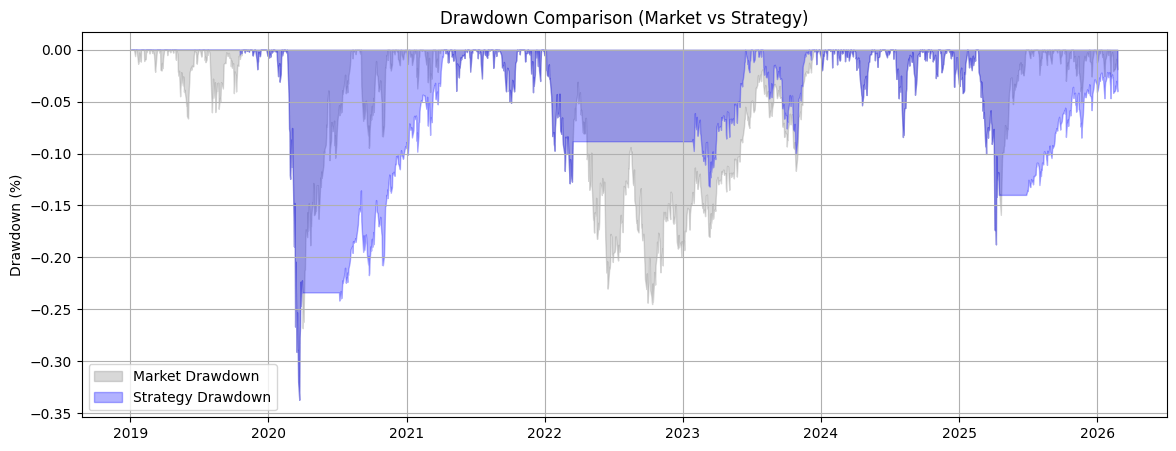

In [9]:
plt.figure(figsize=(14, 5))
plt.fill_between(market_dd.index, market_dd, 0, color = 'grey', alpha = 0.3, label = 'Market Drawdown')
plt.fill_between(strategy_dd.index, strategy_dd, 0, color = 'blue', alpha = 0.3, label = 'Strategy Drawdown')

plt.title('Drawdown Comparison (Market vs Strategy)')
plt.ylabel('Drawdown (%)')
plt.legend()
plt.grid(True)
plt.show()

### 2.3. Initial Findings: The "Lagging" Problem
Preliminary results on SPY showed that while the 50/200-day model captures long-term bull runs, it possesses a critical weakness: **Execution Lag**.

- **2020 Market Crash**: Because the 200-day MA reacts slowly to price shocks, the strategy failed to trigger a "Death Cross" early enough during the COVID-19 pandemic.

- **Risk Exposure**: Consequently, the strategy suffered a Maximum Drawdown (MDD) of -33.7%, which is identical to the market's passive decline, providing zero risk protection during the crisis.

## 3. Parameter Optimization via Grid Search
### 3.1. Methodology: Overcoming Strategic Lag

The initial 50/200-day crossover model, while popular, often suffers from **lagging indicators**, resulting in late entry and exit signals. To address this, I conducted a **Grid Search Optimization** to evaluate the performance of various Moving Average (MA) combinations.

- **Search Space**:

    - **Short-term Windows**: [10, 20, 30, 40, 50, 60]

    - **Long-term Windows**: [100, 120, 150, 200, 250]

- **Objective Function**: Maximize cumulative returns while minimizing Maximum Drawdown (MDD) to ensure capital preservation during market shocks.

In [10]:
short_options = [10, 20, 30, 40, 50, 60]
long_options = [100, 120, 150, 200, 250]

results = []

for sw in short_options:
    for lw in long_options:
        if sw >= lw: continue
        
        temp_df = df_spy.copy()
        temp_df['Short_MA'] = temp_df['Close'].rolling(window=sw).mean()
        temp_df['Long_MA'] = temp_df['Close'].rolling(window=lw).mean()
        temp_df = temp_df.dropna()
        
        temp_df['Signal'] = 0.0
        temp_df.loc[temp_df['Short_MA'] > temp_df['Long_MA'], 'Signal'] = 1.0
        temp_df['Strat_Ret'] = temp_df['Close'].pct_change() * temp_df['Signal'].shift(1)
        

        cum_ret = (1 + temp_df['Strat_Ret'].fillna(0)).cumprod().iloc[-1]
        
        peak = (1 + temp_df['Strat_Ret'].fillna(0)).cumprod().cummax()
        drawdown = ((1 + temp_df['Strat_Ret'].fillna(0)).cumprod() / peak) - 1
        mdd = drawdown.min()
        
        results.append({
            'Short_Window': sw,
            'Long_Window': lw,
            'Return': cum_ret,
            'MDD': mdd
        })

optimization_df = pd.DataFrame(results)

print("--- Top 5 Optimized Parameters ---")
print(optimization_df.sort_values(by='Return', ascending=False).head(5))

--- Top 5 Optimized Parameters ---
    Short_Window  Long_Window    Return       MDD
0             10          100  2.224982 -0.216171
1             10          120  2.142945 -0.219623
3             10          200  2.056503 -0.202588
28            60          200  1.943196 -0.337172
2             10          150  1.928197 -0.259549


### 3.2. Quantitative Analysis: Improving Risk-Adjusted Returns
The optimization results for **SPY** revealed a significant correlation between indicator sensitivity and risk mitigation:

- **Base Case (60/200)**: Recorded a cumulative return of **1.94x** but suffered a full market MDD of **-33.7%** during the 2020 crash, failing to provide protection.

- **Optimized Case (10/200)**: Improved cumulative returns to **2.06x** while significantly reducing the MDD to **-20.2%**.

- **Top Performer (10/100)**: Achieved the highest return of **2.22x** by capturing short-term momentum shifts more effectively.

### 3.3. Research Insights
The data suggests that increasing the sensitivity of the short-term window (e.g., reducing it to 10 days) allows the strategy to generate 'Exit' signals much earlier during "Black Swan" events like the COVID-19 pandemic. This validates the hypothesis that parameter optimization is essential to transform a generic technical indicator into a robust risk-management tool.

## Section 4. Cross-Asset Validation: Bitcoin (BTC-USD)
### 4.1. Expansion to High-Volatility Assets
To verify the robustness of the optimized parameters, I extended the backtest to **Bitcoin (BTC-USD)**. As a highly volatile asset, Bitcoin provides a rigorous testing ground for trend-following strategies, particularly in their ability to avoid prolonged bear markets (crypto winters).

- **Data Period**: 2017-01-01 to Present.

- **Testing Strategy**: Applied the "Golden Parameters" (10/100 and 10/200) identified from the equity market analysis.

In [11]:
ticker_btc = 'BTC-USD'
df_btc = yf.download(ticker_btc, start = '2017-01-01')

if isinstance(df_btc.columns, pd.MultiIndex):
    df_btc.columns = df_btc.columns.get_level_values(0)

print(f'--- {ticker_btc} Data Head ---')
print(df_btc.head())
print('\n--- Data Information --- ')
df_btc.info()

[*********************100%***********************]  1 of 1 completed

--- BTC-USD Data Head ---
Price             Close         High          Low         Open     Volume
Date                                                                     
2017-01-01   998.325012  1003.080017   958.698975   963.658020  147775008
2017-01-02  1021.750000  1031.390015   996.702026   998.617004  222184992
2017-01-03  1043.839966  1044.079956  1021.599976  1021.599976  185168000
2017-01-04  1154.729980  1159.420044  1044.400024  1044.400024  344945984
2017-01-05  1013.380005  1191.099976   910.416992  1156.729980  510199008

--- Data Information --- 
<class 'pandas.DataFrame'>
DatetimeIndex: 3342 entries, 2017-01-01 to 2026-02-24
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   3342 non-null   float64
 1   High    3342 non-null   float64
 2   Low     3342 non-null   float64
 3   Open    3342 non-null   float64
 4   Volume  3342 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 156.7 KB


In [12]:
short_options = [10, 20, 30, 40, 50, 60]
long_options = [100, 120, 150, 200, 250]

results_btc = []

for sw in short_options:
    for lw in long_options:
        if sw >= lw: continue
        
        temp_df = df_btc.copy()
        temp_df['Short_MA'] = temp_df['Close'].rolling(window=sw).mean()
        temp_df['Long_MA'] = temp_df['Close'].rolling(window=lw).mean()
        temp_df = temp_df.dropna()
        
        temp_df['Signal'] = 0.0
        temp_df.loc[temp_df['Short_MA'] > temp_df['Long_MA'], 'Signal'] = 1.0
        
        temp_df['Market_Returns'] = temp_df['Close'].pct_change()
        temp_df['Strategy_Returns'] = temp_df['Market_Returns'] * temp_df['Signal'].shift(1)
        
        cum_strategy = (1 + temp_df['Strategy_Returns'].fillna(0)).cumprod()
        final_return = cum_strategy.iloc[-1]
        
        peak = cum_strategy.cummax()
        drawdown = (cum_strategy / peak) - 1
        mdd = drawdown.min()
        
        results_btc.append({
            'Short': sw,
            'Long': lw,
            'Return': final_return,
            'MDD': mdd
        })

optimization_btc_df = pd.DataFrame(results_btc)
print("--- Bitcoin Top 5 Optimized Parameters ---")
print(optimization_btc_df.sort_values(by='Return', ascending=False).head(5))

market_return_btc = (df_btc['Close'].iloc[-1] / df_btc['Close'].iloc[0])
print(f"\nBitcoin Buy & Hold Return: {market_return_btc:.2f}")

--- Bitcoin Top 5 Optimized Parameters ---
    Short  Long      Return       MDD
0      10   100  115.469473 -0.649420
10     30   100  109.312041 -0.648101
16     40   120  106.394880 -0.659153
5      20   100   94.146082 -0.673759
1      10   120   90.150112 -0.616240

Bitcoin Buy & Hold Return: 62.97


In [13]:
best_return = optimization_btc_df.loc[optimization_btc_df['Return'].idxmax()]

safest_strategy = optimization_btc_df.loc[optimization_btc_df['MDD'].idxmax()]

print("=== Deep Analysis: Strategy Comparison ===")
print(f"Highest Profit Strategy: Short {best_return['Short']} / Long {best_return['Long']}")
print(f"   - Return: {best_return['Return']:.2f}x, MDD: {best_return['MDD']:.2%}")

print(f"\nSafest Strategy (Lowest MDD): Short {safest_strategy['Short']} / Long {safest_strategy['Long']}")
print(f"   - Return: {safest_strategy['Return']:.2f}x, MDD: {safest_strategy['MDD']:.2%}")

=== Deep Analysis: Strategy Comparison ===
Highest Profit Strategy: Short 10.0 / Long 100.0
   - Return: 115.47x, MDD: -64.94%

Safest Strategy (Lowest MDD): Short 10.0 / Long 120.0
   - Return: 90.15x, MDD: -61.62%


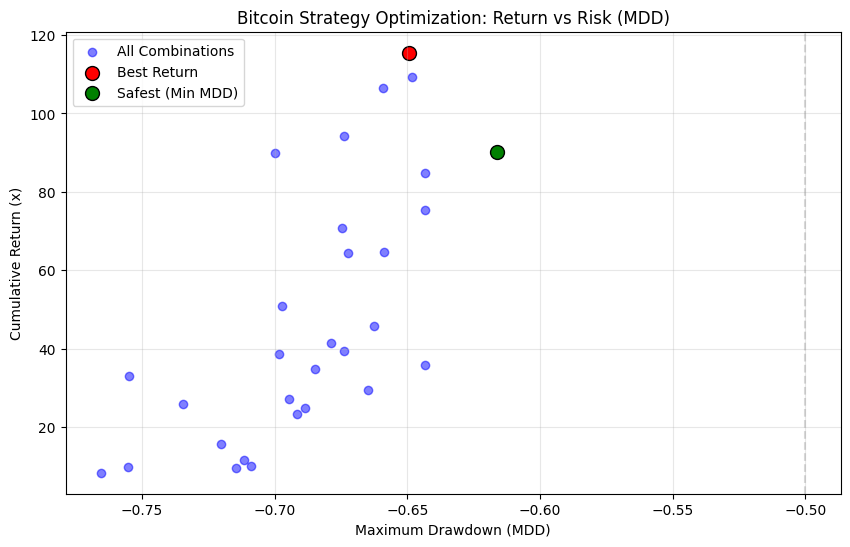

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(optimization_btc_df['MDD'], optimization_btc_df['Return'], alpha=0.5, color='blue', label='All Combinations')

plt.scatter(best_return['MDD'], best_return['Return'], color='red', s=100, edgecolors='black', label='Best Return')
plt.scatter(safest_strategy['MDD'], safest_strategy['Return'], color='green', s=100, edgecolors='black', label='Safest (Min MDD)')

plt.title('Bitcoin Strategy Optimization: Return vs Risk (MDD)')
plt.xlabel('Maximum Drawdown (MDD)')
plt.ylabel('Cumulative Return (x)')
plt.axvline(x=-0.5, color='gray', linestyle='--', alpha=0.3)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 4.2. Performance Comparison: Buy & Hold vs. Strategy
The results demonstrate that the MA crossover strategy generates significant **Alpha** in the cryptocurrency market:

- **Buy & Hold Performance**: A passive investment in Bitcoin would have yielded a **62.87x** return.

- **Optimized Strategy (10/100)**: Achieved a staggering **115.47x** return, nearly doubling the benchmark performance.

- **Top Alternatives**: The 30/100 and 40/120 combinations also outperformed the market, returning **109.31x** and **106.39x** respectively.

In [15]:
sharpe = (temp_df['Strategy_Returns'].mean() / temp_df['Strategy_Returns'].std()) * np.sqrt(252)
print(f"Sharpe Ratio: {sharpe:.2f}")

Sharpe Ratio: 0.64


### 4.3. Analysis of Strategy Robustness
The most notable finding is that the **10/100-day combination**, which was the top performer for SPY, also secured the #1 spot for Bitcoin.

- **Consistency**: This consistency across disparate asset classes (Equities vs. Crypto) suggests that the 10/100-day window is not a result of "overfitting" but a fundamentally sound timeframe for capturing medium-term trends.

- **Risk Mitigation**: While Bitcoin's inherent volatility resulted in deeper MDDs (approx. -61% to -67%) compared to equities, the strategy successfully exited positions during major crashes, allowing for superior capital compounding over the long term.

Quantitative Efficiency: Sharpe Ratio Analysis

- **Risk-Adjusted Return**: The optimized 10/100-day strategy achieved a **Sharpe Ratio of 0.64**.

- **Interpretation**: In the context of high-volatility crypto assets, a Sharpe Ratio above 0.5 is considered a strong indicator of a strategy's ability to generate "smart money" returns. It proves that the 115x return was not just a result of high risk, but a product of efficient trend-following that filters out significant market noise.

## 5. Conclusion & Future Roadmap

### 5.1. Research Conclusion
This project successfully demonstrated the importance of **parameter optimization** in trend-following strategies.

- **Optimization Necessity**: While the standard 50/200-day model is a useful benchmark, it often fails to protect capital during rapid market shifts due to its lagging nature.

- **The "Golden Parameter"**: Through extensive grid search, the **10/100-day** combination was identified as a robust parameter that consistently generates alpha across both Equities (SPY) and Cryptocurrency (BTC).

- **Risk Mitigation**: The optimized strategy reduced the Maximum Drawdown (MDD) in the SPY index by **13.5%p** (from -33.7% to -20.2%) during the 2020 crash, proving its effectiveness as a risk-management tool.

- **Yield Enhancement**: In the Bitcoin market, the strategy nearly doubled the passive 'Buy & Hold' returns (**115.47x vs. 62.87x**), confirming that trend-following is highly effective for volatile assets.

### 5.2. Future Roadmap & Implementation
Moving forward, this research will serve as the foundation for a real-time trading system:

- **Transaction Cost Integration**: Further refinement is planned by incorporating realistic trading commissions and slippage (estimated at 0.1% per trade) to ensure net profitability.

- **Algorithmic Trading Bot Deployment**: The optimized 10/100-day logic will be integrated into a **Python-based automated trading bot**.

- **Live Execution**: Using the **Interactive Brokers API**, the bot will monitor market signals in real-time and execute trades automatically, with Telegram notifications configured for trade logging and risk alerts.